Cell 1 — Install Libraries

In [81]:
!pip install pycryptodome pillow numpy matplotlib

Cell 2 — Import Libraries

In [82]:
from Crypto.Cipher import AES
from Crypto.Util.Padding import pad, unpad

from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

Cell 3 — Load the Image

Image shape: (401, 642, 4)


(np.float64(-0.5), np.float64(641.5), np.float64(400.5), np.float64(-0.5))

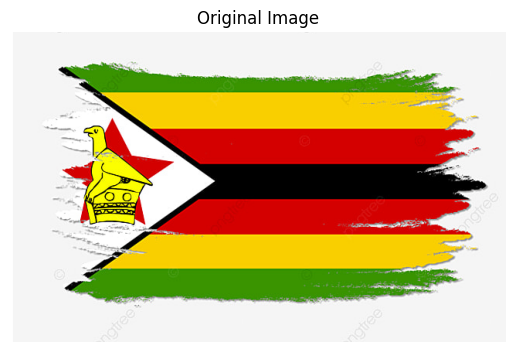

In [83]:
image_path = "crypto-image.png"

img = Image.open(image_path)
img_array = np.array(img)

print("Image shape:", img_array.shape)

plt.imshow(img_array)
plt.title("Original Image")
plt.axis("off")

Cell 4 — Prepare Image Data

In [84]:
# pixel data (for ECB, CTR, GCM visualization)
pixel_data = img_array.tobytes()

# full image file data (for CBC encryption)
with open(image_path, "rb") as f:
    file_data = f.read()

print("Pixel bytes:", len(pixel_data))
print("File bytes:", len(file_data))

Pixel bytes: 1029768
File bytes: 172408


Cell 5 — Generate AES Key

In [85]:
key_string = "sevennaturalwondersoftheworld!!!"

key = key_string.encode()

print("AES Key:", key_string)
print("Key length:", len(key))

AES Key: sevennaturalwondersoftheworld!!!
Key length: 32


Cell 6 — ECB Encryption

In [86]:
cipher_ecb = AES.new(key, AES.MODE_ECB)

ecb_ciphertext = cipher_ecb.encrypt(pad(pixel_data,16))

encrypted = np.frombuffer(ecb_ciphertext[:len(pixel_data)], dtype=np.uint8)
encrypted = encrypted.reshape(img_array.shape)

Cell 7 — CBC Encryption

In [87]:
iv = get_random_bytes(16)

cipher = AES.new(key, AES.MODE_CBC, iv)

ciphertext = cipher.encrypt(pad(file_data,16))

with open("cbc-aes-picture.img","wb") as f:
    f.write(ciphertext)

print("Mode: CBC")
print("Secret Key:", key_string)
print("IV (HEX):", iv.hex())

Mode: CBC
Secret Key: sevennaturalwondersoftheworld!!!
IV (HEX): 7f29934a987b7d890d4da000a66986c4


Cell 8 — CTR Encryption

In [88]:
cipher = AES.new(key, AES.MODE_CTR)

ciphertext = cipher.encrypt(pixel_data)

encrypted = np.frombuffer(ciphertext[:len(pixel_data)], dtype=np.uint8)
encrypted = encrypted.reshape(img_array.shape)

Cell 9 — GCM Encryption (Strongest)

In [89]:
cipher = AES.new(key, AES.MODE_GCM)

ciphertext, tag = cipher.encrypt_and_digest(pixel_data)

encrypted = np.frombuffer(ciphertext[:len(pixel_data)], dtype=np.uint8)
encrypted = encrypted.reshape(img_array.shape)

Cell 10 — ECB Decryption Test

(np.float64(-0.5), np.float64(641.5), np.float64(400.5), np.float64(-0.5))

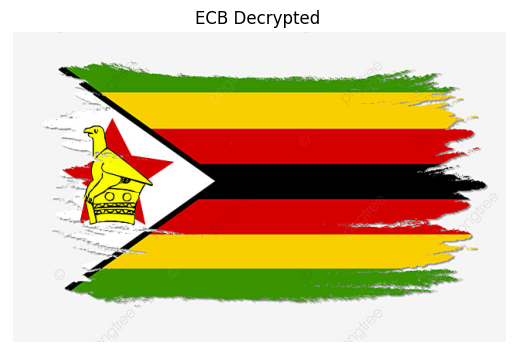

In [90]:
cipher = AES.new(key, AES.MODE_ECB)

plaintext = unpad(cipher.decrypt(ecb_ciphertext),16)

recovered = np.frombuffer(plaintext[:len(pixel_data)], dtype=np.uint8)
recovered = recovered.reshape(img_array.shape)

Image.fromarray(recovered).save("ECBdecrypted.png")

plt.imshow(recovered)
plt.title("ECB Decrypted")
plt.axis("off")

Cell 11 — CBC Decryption Code

(np.float64(-0.5), np.float64(641.5), np.float64(400.5), np.float64(-0.5))

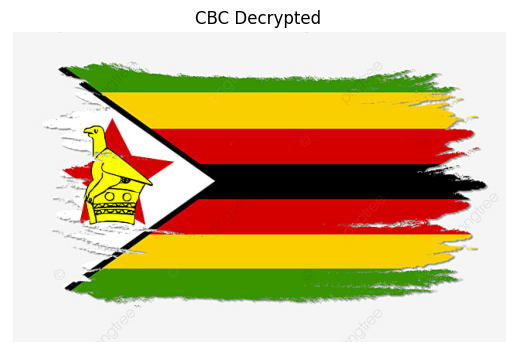

In [91]:
from Crypto.Cipher import AES
from Crypto.Util.Padding import unpad

# your key
key_string = "sevennaturalwondersoftheworld!!!"
key = key_string.encode()

# IV printed from Cell 7
iv = bytes.fromhex("c451daa4c099bb68fee0e89bbe647437")

with open("cbc_encrypted.bin","rb") as f:
    ciphertext = f.read()

cipher = AES.new(key, AES.MODE_CBC, iv)

plaintext = unpad(cipher.decrypt(ciphertext),16)

recovered = np.frombuffer(plaintext, dtype=np.uint8)
recovered = recovered.reshape(img_array.shape)

Image.fromarray(recovered).save("cbc_decrypted.png")

plt.imshow(recovered)
plt.title("CBC Decrypted")
plt.axis("off")